<a href="https://www.kaggle.com/code/sonawanelalitsunil/membership-grocery-store-user-profile-ml-58?scriptVersionId=232770040" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/membership-groceries-user-profile/membership_groceries_userprofile.csv


### Title: Membership Grocery Store User Profile

##### Description: Overview of user preferences, shopping habits, and membership details for personalized grocery store experiences.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/membership-groceries-user-profile/membership_groceries_userprofile.csv')

In [3]:
df.head()

,id,gender,shared_account,membership_tier,membership_auto_renew,membership_fee,membership_start_date,push_notification_enabled,have_app,app_engagement_score,bought_store_brand,promotion_participation_count,average_basket_size,use_count,reward_points_used
0,1,Male,0,standard,1,188,2023/6/25,1,1,84.64,0,2,385.77,14,107
1,2,Female,0,standard,0,188,2019/4/14,1,1,83.78,1,3,126.74,14,149
2,3,Female,0,standard,0,188,2021/10/4,0,0,0.00,0,5,668.71,7,87
3,4,Male,0,standard,1,188,2023/11/22,0,1,51.31,1,2,194.62,12,67
4,5,Female,1,premium,1,388,2019/10/8,1,1,70.82,0,1,519.91,7,120


In [4]:
df.tail()

,id,gender,shared_account,membership_tier,membership_auto_renew,membership_fee,membership_start_date,push_notification_enabled,have_app,app_engagement_score,bought_store_brand,promotion_participation_count,average_basket_size,use_count,reward_points_used
853,854,Female,0,standard,1,188,2024/3/30,0,0,0.00,1,3,446.56,12,0
854,855,Female,0,standard,1,188,2019/10/18,1,1,58.71,0,2,149.41,7,0
855,856,Male,1,standard,1,188,2024/4/9,0,0,0.00,1,3,482.99,10,101
856,857,Female,1,premium,1,388,2022/10/12,1,1,48.00,1,4,395.57,11,60
857,858,Male,0,standard,1,188,2024/2/22,1,1,62.48,0,3,314.41,9,69


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             858 non-null    int64  
 1   gender                         858 non-null    object 
 2   shared_account                 858 non-null    int64  
 3   membership_tier                858 non-null    object 
 4   membership_auto_renew          858 non-null    int64  
 5   membership_fee                 858 non-null    int64  
 6   membership_start_date          858 non-null    object 
 7   push_notification_enabled      858 non-null    int64  
 8   have_app                       858 non-null    int64  
 9   app_engagement_score           858 non-null    float64
 10  bought_store_brand             858 non-null    int64  
 11  promotion_participation_count  858 non-null    int64  
 12  average_basket_size            858 non-null    flo

In [6]:
df.describe()

,id,shared_account,membership_auto_renew,membership_fee,push_notification_enabled,have_app,app_engagement_score,bought_store_brand,promotion_participation_count,average_basket_size,use_count,reward_points_used
count,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000
mean,429.500000,0.224942,0.780886,270.284382,0.517483,0.748252,51.830897,0.493007,2.969697,436.723508,11.301865,92.835664
std,247.827561,0.417787,0.413887,98.475679,0.499986,0.434271,32.556343,0.500243,1.942947,283.632009,2.590895,46.959699
min,1.000000,0.000000,0.000000,188.000000,0.000000,0.000000,0.000000,0.000000,0.000000,40.000000,4.000000,0.000000
25%,215.250000,0.000000,1.000000,188.000000,0.000000,0.000000,0.000000,0.000000,2.000000,258.162500,10.000000,59.000000
50%,429.500000,0.000000,1.000000,188.000000,1.000000,1.000000,62.965000,0.000000,3.000000,355.235000,11.000000,95.000000
75%,643.750000,0.000000,1.000000,388.000000,1.000000,1.000000,75.892500,1.000000,4.000000,534.317500,13.000000,126.750000
max,858.000000,1.000000,1.000000,388.000000,1.000000,1.000000,95.000000,1.000000,9.000000,1500.000000,18.000000,200.000000


In [7]:
df.isnull().sum()

id                               0
gender                           0
shared_account                   0
membership_tier                  0
membership_auto_renew            0
membership_fee                   0
membership_start_date            0
push_notification_enabled        0
have_app                         0
app_engagement_score             0
bought_store_brand               0
promotion_participation_count    0
average_basket_size              0
use_count                        0
reward_points_used               0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(858, 15)

In [10]:
df.dtypes

id                                 int64
gender                            object
shared_account                     int64
membership_tier                   object
membership_auto_renew              int64
membership_fee                     int64
membership_start_date             object
push_notification_enabled          int64
have_app                           int64
app_engagement_score             float64
bought_store_brand                 int64
promotion_participation_count      int64
average_basket_size              float64
use_count                          int64
reward_points_used                 int64
dtype: object

In [11]:
df.columns

Index(['id', 'gender', 'shared_account', 'membership_tier',
       'membership_auto_renew', 'membership_fee', 'membership_start_date',
       'push_notification_enabled', 'have_app', 'app_engagement_score',
       'bought_store_brand', 'promotion_participation_count',
       'average_basket_size', 'use_count', 'reward_points_used'],
      dtype='object')

## Data visualizations

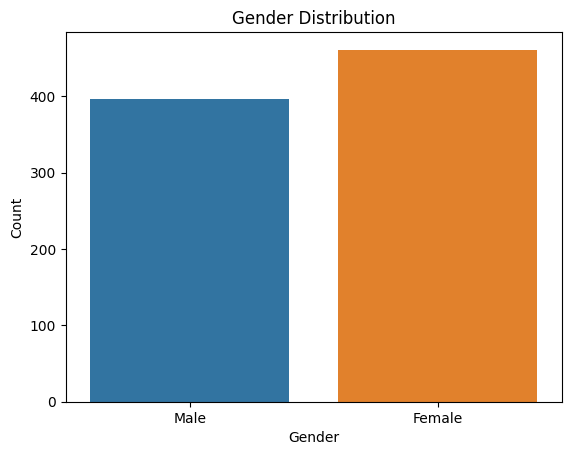

In [12]:
sns.countplot(data=df, x='gender')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()


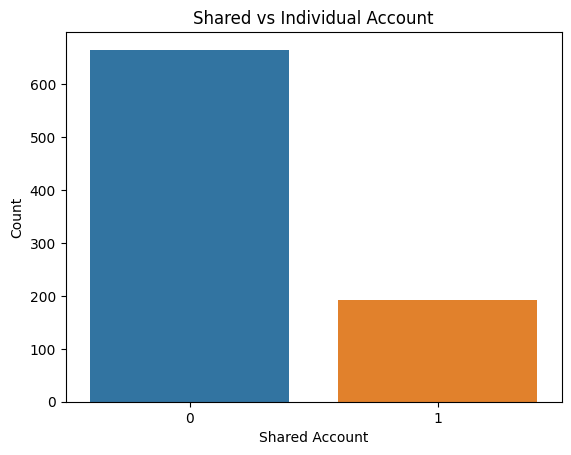

In [13]:
sns.countplot(data=df, x='shared_account')
plt.title('Shared vs Individual Account')
plt.xlabel('Shared Account')
plt.ylabel('Count')
plt.show()


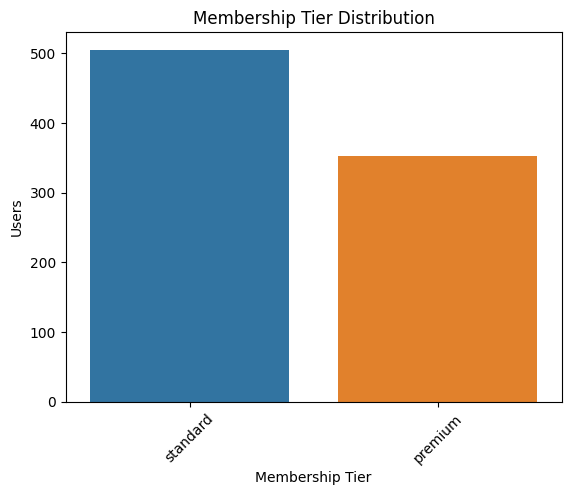

In [14]:
sns.countplot(data=df, x='membership_tier', order=df['membership_tier'].value_counts().index)
plt.title('Membership Tier Distribution')
plt.xlabel('Membership Tier')
plt.ylabel('Users')
plt.xticks(rotation=45)
plt.show()


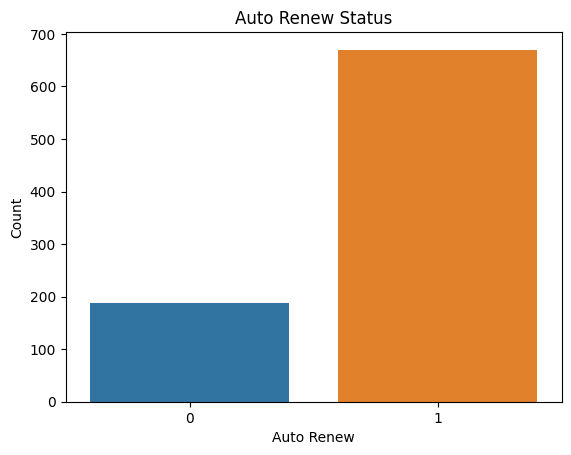

In [15]:
sns.countplot(data=df, x='membership_auto_renew')
plt.title('Auto Renew Status')
plt.xlabel('Auto Renew')
plt.ylabel('Count')
plt.show()


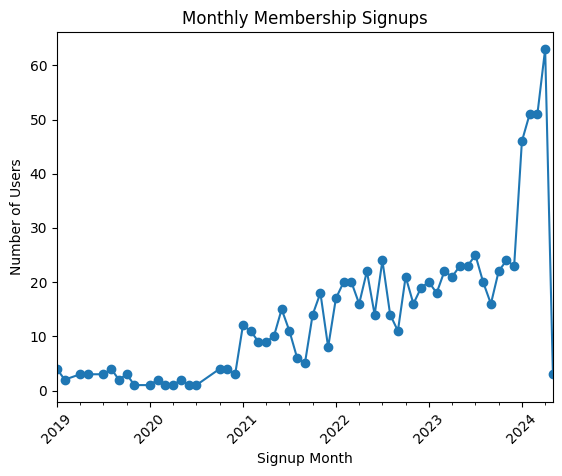

In [16]:
df['membership_start_date'] = pd.to_datetime(df['membership_start_date'])
df['signup_month'] = df['membership_start_date'].dt.to_period('M')

df.groupby('signup_month').size().plot(kind='line', marker='o')
plt.title('Monthly Membership Signups')
plt.xlabel('Signup Month')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.show()


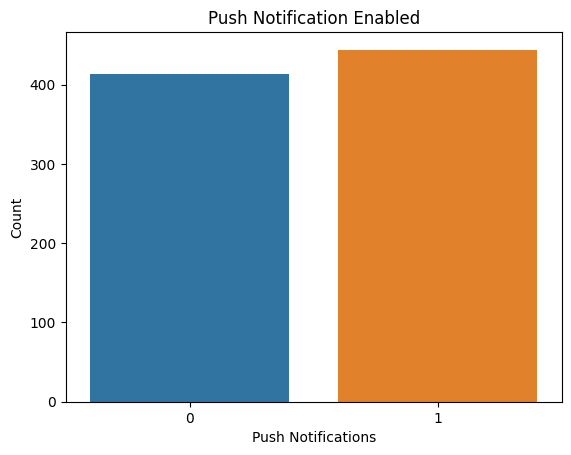

In [17]:
sns.countplot(data=df, x='push_notification_enabled')
plt.title('Push Notification Enabled')
plt.xlabel('Push Notifications')
plt.ylabel('Count')
plt.show()


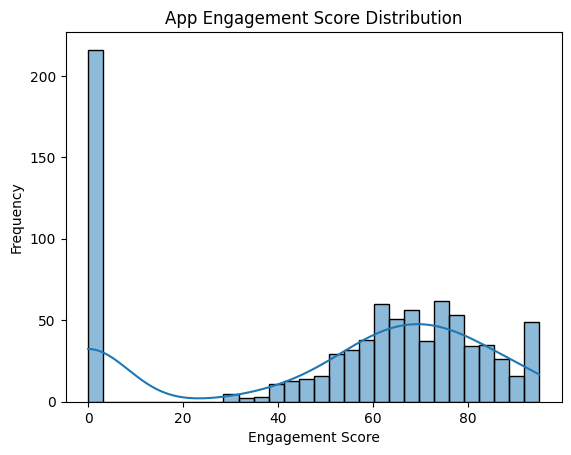

In [18]:
sns.histplot(df['app_engagement_score'], bins=30, kde=True)
plt.title('App Engagement Score Distribution')
plt.xlabel('Engagement Score')
plt.ylabel('Frequency')
plt.show()


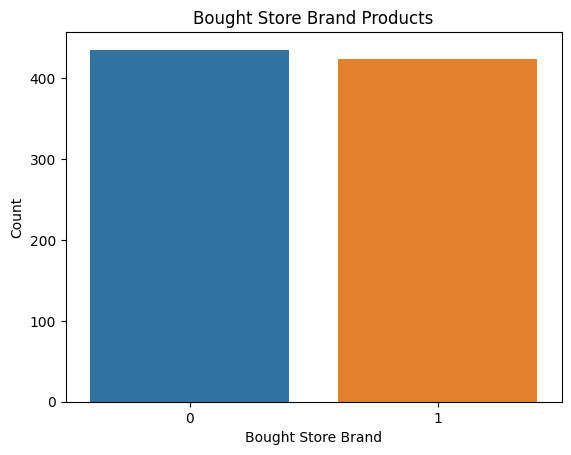

In [19]:
sns.countplot(data=df, x='bought_store_brand')
plt.title('Bought Store Brand Products')
plt.xlabel('Bought Store Brand')
plt.ylabel('Count')
plt.show()


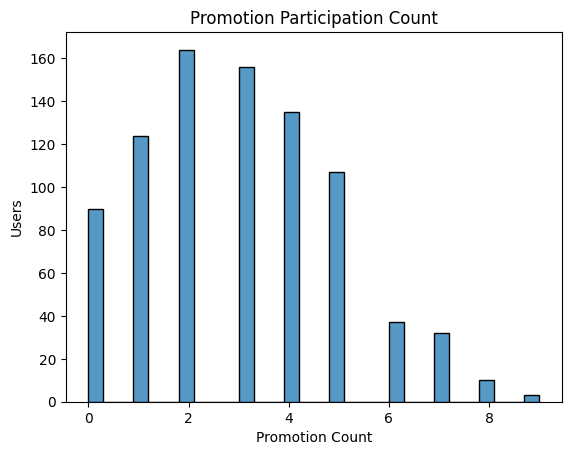

In [20]:
sns.histplot(df['promotion_participation_count'], bins=30)
plt.title('Promotion Participation Count')
plt.xlabel('Promotion Count')
plt.ylabel('Users')
plt.show()


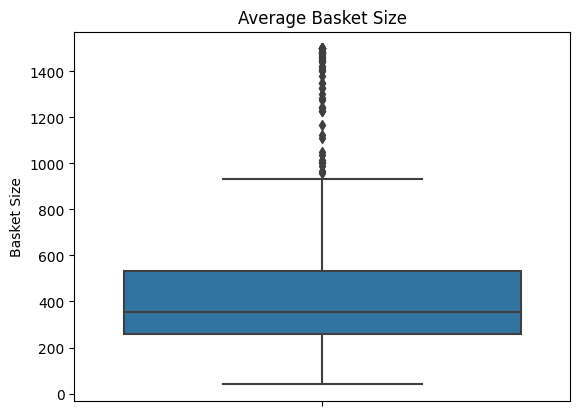

In [21]:
sns.boxplot(data=df, y='average_basket_size')
plt.title('Average Basket Size')
plt.ylabel('Basket Size')
plt.show()


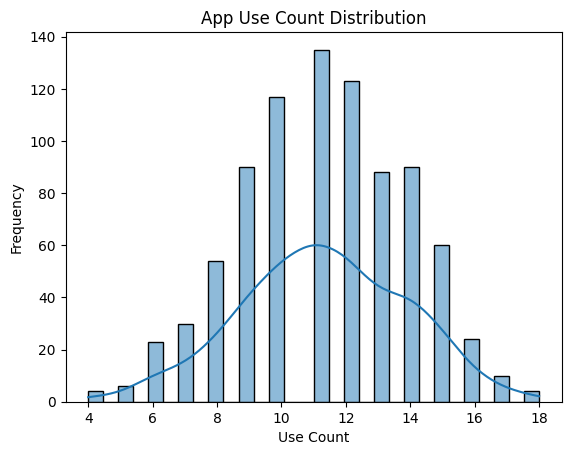

In [22]:
sns.histplot(df['use_count'], bins=30, kde=True)
plt.title('App Use Count Distribution')
plt.xlabel('Use Count')
plt.ylabel('Frequency')
plt.show()


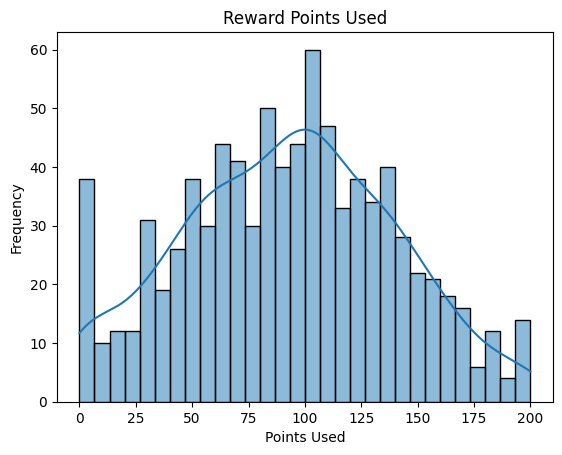

In [23]:
sns.histplot(df['reward_points_used'], bins=30, kde=True)
plt.title('Reward Points Used')
plt.xlabel('Points Used')
plt.ylabel('Frequency')
plt.show()


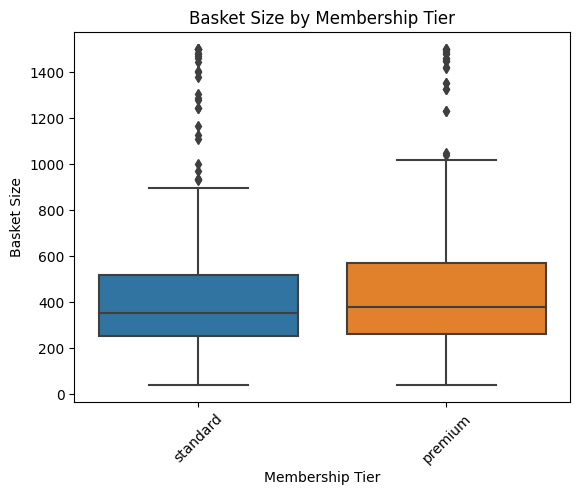

In [24]:
sns.boxplot(data=df, x='membership_tier', y='average_basket_size')
plt.title('Basket Size by Membership Tier')
plt.xlabel('Membership Tier')
plt.ylabel('Basket Size')
plt.xticks(rotation=45)
plt.show()


## Predictve modeling

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [27]:
df_model = df.copy()
df_model = df_model.drop(columns=[col for col in ['id', 'membership_start_date'] if col in df_model.columns])

In [28]:
# Step 2: Fix Period dtype (signup_month)
if 'signup_month' in df_model.columns and df_model['signup_month'].dtype.name == 'period[M]':
    df_model['signup_month'] = df_model['signup_month'].astype(str)

In [29]:
# Step 3: Encode categorical variables
le = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

In [30]:
# Step 4: Train-Test Split
X = df_model.drop('reward_points_used', axis=1)
y = df_model['reward_points_used']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
# Step 5: Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Support Vector Machine': SVC(),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

In [32]:
# Step 6: Train and Evaluate
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    cm = confusion_matrix(y_test, preds)
    results.append((name, acc))

    print(f"📊 {name} Accuracy: {acc:.2f}%")
    print("Confusion Matrix:")
    print(cm)
    print("-" * 50)

📊 Logistic Regression Accuracy: 1.74%
Confusion Matrix:
[[3 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
--------------------------------------------------
📊 Decision Tree Accuracy: 0.00%
Confusion Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
--------------------------------------------------
📊 Random Forest Accuracy: 1.16%
Confusion Matrix:
[[1 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
--------------------------------------------------
📊 Gradient Boosting Accuracy: 0.58%
Confusion Matrix:
[[1 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
--------------------------------------------------
📊 Support Vector Machine Accuracy: 3.49%
Confusion Matrix:
[[6 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [1 0 0 .

In [33]:
# Step 7: Visualize Accuracy
model_names = [r[0] for r in results]
accuracies = [r[1] for r in results]


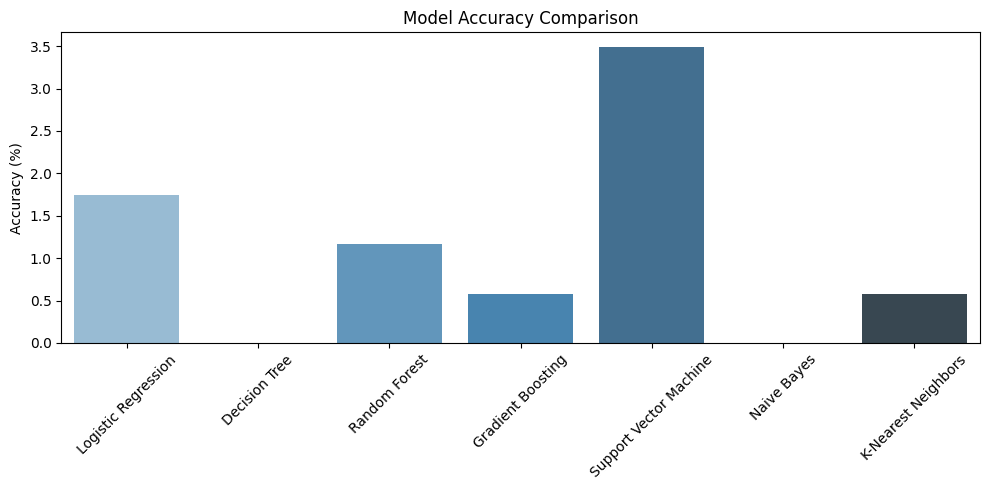

In [34]:
plt.figure(figsize=(10, 5))
sns.barplot(x=model_names, y=accuracies, palette="Blues_d")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()